. Setup Ambiente e Pre-processing Dati
In questa sezione vengono importate le librerie necessarie per la manipolazione dei dati e la costruzione dei modelli (Pandas, Scikit-Learn, Matplotlib).

Viene inoltre definita la funzione helper series_to_supervised. Tale funzione è cruciale per adattare i dati di serie storiche alle reti neurali: converte il dataset sequenziale in un formato adatto all'apprendimento supervisionato applicando il metodo della Sliding Window (finestra scorrevole).

Input (n_in): Genera le feature ritardate (lag) al tempo t−n.

Output (n_out): Genera i target di previsione al tempo t+n.

In [6]:
from pandas import read_csv
from matplotlib import pyplot
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler
import pandas as pd # Import pandas

# convert series to supervised learning Questa funzione trasforma un dataset di serie storiche in un problema di apprendimento supervisionato.
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = 1 if type(data) is list else data.shape[1]
    df = pd.DataFrame(data)
    cols, names = list(), list()
    # input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    # forecast sequence (t, t+1, ... t+n)
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
    # put it all together
    agg = pd.concat(cols, axis=1)
    agg.columns = names # Assign the generated names to the columns
    # drop rows with NaN values
    if dropnan:
        agg.dropna(inplace=True)
    return agg




2. Acquisizione del Dataset
In questa fase viene caricato il file contenente i dati storici di mercato ("Dataset finale 4 anni"). Il caricamento prevede:

La corretta interpretazione del formato numerico europeo (virgola per i decimali, punto per le migliaia) per evitare errori di parsing.

L'estrazione della matrice dei valori (dataset.values), convertendo il DataFrame in un array NumPy pronto per essere processato dalle reti neurali.



In [7]:
import pandas as pd
from sklearn.preprocessing import RobustScaler
import numpy as np

# 1. Caricamento dei  dati separati come segue .
dataset = pd.read_csv('/content/../data/dataset_finale_4_anni.csv',
    header=0,
    index_col=0,
    decimal=',',
    thousands='.'
)

# 2. Prendi i valori.
values = dataset.values


print(values)
values.shape

[[4331.27 1811.57  170.28]
 [3983.88 1367.67  155.72]
 [3704.99 1334.19  147.09]
 ...
 [6095.3  4452.5   115.77]
 [5468.4  3811.3   105.1 ]
 [4921.7  3306.7    98.53]]


(33504, 3)

3. Segmentazione Stagionale e Definizione degli Scenari di Test
In questa fase, il dataset completo viene suddiviso in specifiche finestre temporali corrispondenti alle diverse stagioni (Autunno, Inverno, Primavera, Estate). Questa operazione è fondamentale per valutare la robustezza dei modelli previsivi in diverse condizioni di mercato (es. alta volatilità invernale vs stabilità estiva).

Il codice seguente:

Definisce gli indici riga esatti di inizio e fine per ciascuna stagione (basandosi sul conteggio orario).

Estrae la porzione di dati relativa allo scenario selezionato (in questo caso: Inverno 2024/2025).

Genera un grafico preliminare della variabile target (Prezzo) per verificare visivamente l'andamento della serie storica selezionata prima dell'elaborazione.


Dati caricati. Shape totale: (33504, 3)
Estrazione dati per 'inverno_2024_2025' (righe da 28224 a 30384)
Generazione grafico...


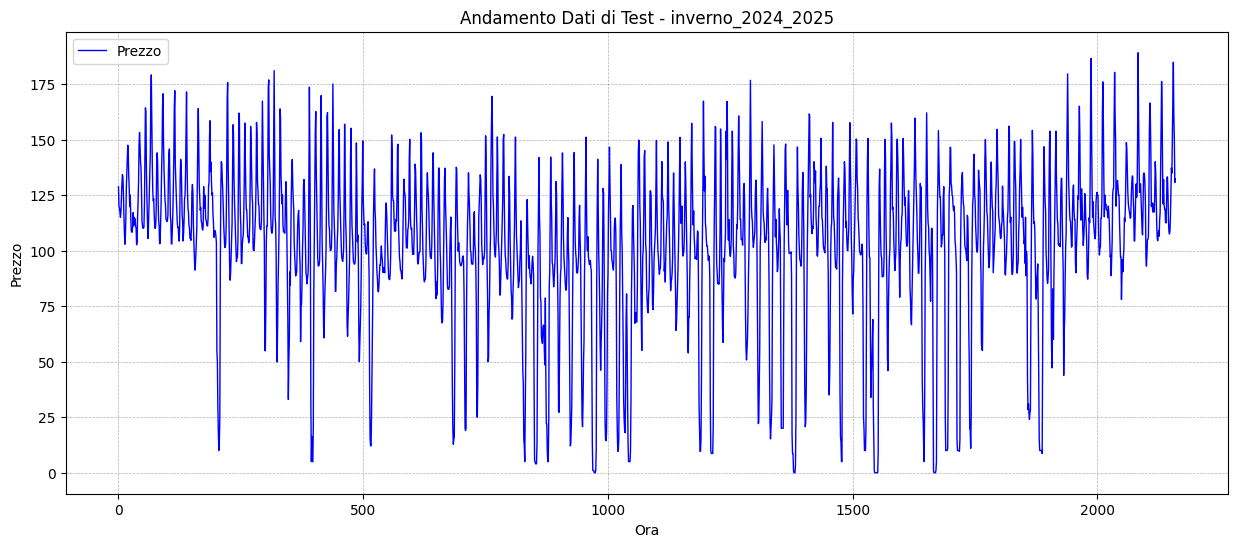

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. IMPOSTAZIONI ---

FILE_CSV = '/content/../data/dataset_finale_4_anni.csv'
RIGA_INIZIO_AUTUNNO_2024 = 26064
STAGIONE_DI_TEST = 'inverno_2024_2025'

# l'indice è 2
# (Colonna 0, Colonna 1, Colonna 2)
COLONNA_PREZZO = 2 # <--- Impostato su 2

# --- 2. CARICAMENTO DATI ---

try:
    dataset = pd.read_csv(FILE_CSV,
        header=0,
        index_col=0,
        decimal=',',
        thousands='.'
    )
except FileNotFoundError:
    print(f"ERRORE: File non trovato. Controlla il percorso: {FILE_CSV}")
    raise

values = dataset.values
print(f"Dati caricati. Shape totale: {values.shape}")

# Controllo che la colonna esista
if values.ndim < 2 or values.shape[1] <= COLONNA_PREZZO:
     print(f"ERRORE: I dati non hanno una colonna all'indice {COLONNA_PREZZO}.")
     print(f"La shape dei dati è {values.shape}. Assicurati che ci siano almeno 3 colonne.")
     raise IndexError("Indice colonna non valido")

# --- 3. CALCOLO POSIZIONI STAGIONI ---

ore_autunno = 2160
ore_inverno = 2160
ore_primavera = 2208
ore_estate = 2232

riga_start_A = RIGA_INIZIO_AUTUNNO_2024
riga_start_I = riga_start_A + ore_autunno
riga_start_P = riga_start_I + ore_inverno
riga_start_E = riga_start_P + ore_primavera
riga_fine_E = riga_start_E + ore_estate

stagioni_test_posizioni = {
    'autunno_2024': (riga_start_A, riga_start_I),
    'inverno_2024_2025': (riga_start_I, riga_start_P),
    'primavera_2025': (riga_start_P, riga_start_E),
    'estate_2025': (riga_start_E, riga_fine_E),
}

# --- 4. ESTRAZIONE DATI DELLA STAGIONE ---

try:
    start_pos, end_pos = stagioni_test_posizioni[STAGIONE_DI_TEST]
except KeyError:
    print(f"ERRORE: La stagione '{STAGIONE_DI_TEST}' non è valida.")
    raise

print(f"Estrazione dati per '{STAGIONE_DI_TEST}' (righe da {start_pos} a {end_pos})")
dati_stagione = values[start_pos:end_pos]

# --- 5. PLOT ---

# Estrai la colonna del prezzo (indice 2)
dati_da_plottare = dati_stagione[:, COLONNA_PREZZO]

print("Generazione grafico...")

plt.figure(figsize=(15, 6))
plt.plot(dati_da_plottare, label=f'Prezzo', color='blue', linewidth=1)


plt.title(f"Andamento Dati di Test - {STAGIONE_DI_TEST}")
plt.xlabel("Ora")
plt.ylabel("Prezzo")
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5)
plt.show()

4. Configurazione dei Set di Test Stagionali
In questa fase cruciale, il dataset viene partizionato in quattro macro-scenari (Autunno, Inverno, Primavera, Estate) per validare le performance del modello su diverse dinamiche di mercato.

La procedura segue questi step:

Identificazione del Trigger Point: Viene fissato l'indice riga 23.856 come punto di inizio esatto della stagione Autunnale 2024.

Calcolo degli Orizzonti: Vengono definiti gli intervalli temporali precisi (in ore) per ogni stagione, garantendo che non ci siano sovrapposizioni (Data Leakage).

Selezione dello Scenario: Il sistema calcola automaticamente gli indici di start/end per tutte le stagioni future, permettendo di selezionare la variabile STAGIONE_DI_TEST (in questo caso: Autunno 2024) per l'esecuzione del modello.


In [33]:
import pandas as pd
from sklearn.preprocessing import RobustScaler

# --- PASSO 1: CARICAMENTO
# Carichiamo i dati.
dataset = pd.read_csv('/content/../data/dataset_finale_4_anni.csv',
    header=0,
    index_col=0,
    decimal=',',
    thousands='.'
)

# --- PASSO 2: PRENDI I 'VALUES' ---
# Lavoriamo direttamente con l'array
values = dataset.values

print(f"Dati caricati. Numero totale di righe (ore): {values.shape[0]}")

# --------------------------------------------------------------------------
# --- PASSO 3: IMPOSTA LA TUA POSIZIONE D'INIZIO QUI ---
#
RIGA_INIZIO_AUTUNNO_2024 = 23856
#
# --------------------------------------------------------------------------

# Calcoliamo le durate (in ore/righe) per ogni stagione
ore_autunno = 2160       # 90 giorni * 24 ore
ore_inverno = 2160       # 90 giorni * 24 ore
ore_primavera = 2208     # 92 giorni * 24 ore
ore_estate = 2232        # 93 giorni * 24 ore

# Calcolo automatico degli start e end
riga_start_A = RIGA_INIZIO_AUTUNNO_2024
riga_start_I = riga_start_A + ore_autunno
riga_start_P = riga_start_I + ore_inverno
riga_start_E = riga_start_P + ore_primavera
riga_fine_E = riga_start_E + ore_estate

stagioni_test_posizioni = {
    # (Riga Inizio Test, Riga Fine Test)
    'autunno_2024': (riga_start_A, riga_start_I),
    'inverno_2024_2025': (riga_start_I, riga_start_P),
    'primavera_2025': (riga_start_P, riga_start_E),
    'estate_2025': (riga_start_E, riga_fine_E),
}

print("\nPosizioni di split calcolate (in base alla tua riga d'inizio):")
print(f"  Autunno:   righe {stagioni_test_posizioni['autunno_2024']}")
print(f"  Inverno:   righe {stagioni_test_posizioni['inverno_2024_2025']}")
print(f"  Primavera: righe {stagioni_test_posizioni['primavera_2025']}")
print(f"  Estate:    righe {stagioni_test_posizioni['estate_2025']}")

# SELEZIONA LA STAGIONE CHE VUOI TESTARE
STAGIONE_DI_TEST = 'autunno_2024'

# --- PASSO 5: SPLIT E SCALING

# 1. Trova i numeri di riga (posizioni)
try:
    start_test_pos, end_test_pos = stagioni_test_posizioni[STAGIONE_DI_TEST]
except KeyError:
    print(f"ERRORE: La stagione '{STAGIONE_DI_TEST}' non esiste nel dizionario.")
    raise

print(f"\n--- Creazione split per test su: {STAGIONE_DI_TEST} ---")



Dati caricati. Numero totale di righe (ore): 33504

Posizioni di split calcolate (in base alla tua riga d'inizio):
  Autunno:   righe (23856, 26016)
  Inverno:   righe (26016, 28176)
  Primavera: righe (28176, 30384)
  Estate:    righe (30384, 32616)

--- Creazione split per test su: autunno_2024 ---


5. Data Splitting e Normalizzazione
Per prevenire il fenomeno del Data Leakage (fuga di informazioni dal futuro), la suddivisione tra set di addestramento (Train) e set di test (Test) rispetta rigorosamente l'ordine cronologico:

Train Set: Comprende l'intero storico antecedente alla stagione target.

Test Set: Comprende esclusivamente la finestra temporale della stagione selezionata.

Successivamente, viene applicata la standardizzazione delle feature. È stato scelto lo sklearn.RobustScaler (invece del classico MinMax o StandardScaler) poiché il mercato elettrico presenta frequenti picchi di prezzo (outliers). Il RobustScaler utilizza la mediana e il range interquartile (IQR), garantendo che la rete neurale non venga influenzata negativamente da questi valori estremi durante la fase di convergenza.

In [34]:

# Train: TUTTO dalla riga 0 fino alla riga 'start_test_pos'
train_values = values[:start_test_pos, :]

# Test: Solo le righe DENTRO l'intervallo stagionale
test_values = values[start_test_pos:end_test_pos, :]

# 3. Controllo
if train_values.shape[0] == 0:
    print("ATTENZIONE: Il set di training è vuoto!")
if test_values.shape[0] == 0:
    print("ATTENZIONE: Il set di test è vuoto!")
else:
    print(f"Righe Training: {train_values.shape[0]} (Tutte le righe fino alla {start_test_pos-1})")
    print(f"Righe Test:     {test_values.shape[0]} (Righe dalla {start_test_pos} alla {end_test_pos-1})")

# --- PASSO 6: SCALING

# SELZIONIAMO LO SCALER.
scaler = RobustScaler()

# Applica .fit_transform() solo al set di training
scaled_train = scaler.fit_transform(train_values)

# Tasforma il test usando i parametri gia imparati dal traning
scaled_test = scaler.transform(test_values)

# 'scaled_train' e 'scaled_test' pronti per i passaggi successivi
print("\nForma dei dati di training scalati:", scaled_train.shape)
print("Forma dei dati di test scalati:", scaled_test.shape)

Righe Training: 23856 (Tutte le righe fino alla 23855)
Righe Test:     2160 (Righe dalla 23856 alla 26015)

Forma dei dati di training scalati: (23856, 3)
Forma dei dati di test scalati: (2160, 3)


6. Costruzione della Finestra Temporale (Sliding Window)
In questa fase, i dati sequenziali vengono riorganizzati in una struttura a finestra scorrevole (Sliding Window) adatta per l'addestramento supervisionato delle reti neurali.

Parametri della struttura:

Input Window (N
IN
​
 ): 72 ore (3 giorni). Il modello utilizzerà le 72 ore precedenti di tutte le feature per apprendere i pattern temporali.

Target (N
OUT
​
 ): 1 ora. L'obiettivo è la previsione del Prezzo Unico Nazionale (PUN) all'ora t.

Rimozione delle Feature Future: La funzione series_to_supervised genera inizialmente anche le variabili esogene al tempo t (es. Carico, Rinnovabili al tempo della previsione). Queste colonne vengono rimosse programmaticamente (cols_to_drop), mantenendo come output (y) esclusivamente la colonna del Prezzo, per evitare il fenomeno del Look-ahead Bias (utilizzare dati futuri non disponibili al momento della previsione).

In [35]:


# Definisci i parametri della finestra temporale
N_IN = 72       # 3 giorni (72 ore) per predire l'ora successiva
N_FEATURES = 3    # Il numero di feature originali

#TRASFORMA IL SET DI TRAINING
reframed_train = series_to_supervised(scaled_train, n_in=N_IN, n_out=1)

# TRASFORMA IL SET DI TEST
reframed_test = series_to_supervised(scaled_test, n_in=N_IN, n_out=1)


#COLONNE DI OUTPUT NON NECESSARIE
# Dobbiamo eliminare le colonne di output non necessarie Vogliamo solo il prezzo
cols_to_drop = []
for i in range(N_FEATURES - 1):
    cols_to_drop.append(N_FEATURES * N_IN + i)

reframed_train.drop(reframed_train.columns[cols_to_drop], axis=1, inplace=True)
reframed_test.drop(reframed_test.columns[cols_to_drop], axis=1, inplace=True)


# Divisione finale IN INPUT (X) E OUTPUT (y)
train_values = reframed_train.values
test_values = reframed_test.values

train_X, train_y = train_values[:, :-1], train_values[:, -1]
test_X, test_y = test_values[:, :-1], test_values[:, -1]


# Verifica finale.
print("--- Set di Training ---")
print("Forma di train_X:", train_X.shape)
print("Forma di train_y:", train_y.shape)
print("\n--- Set di Test ---")
print("Forma di test_X:", test_X.shape)
print("Forma di test_y:", test_y.shape)
print("\nPrime 5 righe del set di training trasformato:")
print(reframed_train.head())

--- Set di Training ---
Forma di train_X: (23784, 216)
Forma di train_y: (23784,)

--- Set di Test ---
Forma di test_X: (2088, 216)
Forma di test_y: (2088,)

Prime 5 righe del set di training trasformato:
    var1(t-72)  var2(t-72)  var3(t-72)  var1(t-71)  var2(t-71)  var3(t-71)  \
72   -0.745770   -0.704520    0.295690   -0.935426   -0.959400    0.172753   
73   -0.935426   -0.959400    0.172753   -1.087684   -0.978623    0.099886   
74   -1.087684   -0.978623    0.099886   -1.177645   -1.050850   -0.373707   
75   -1.177645   -1.050850   -0.373707   -1.215167   -1.077032   -0.263942   
76   -1.215167   -1.077032   -0.263942   -1.171492   -1.083768    0.045088   

    var1(t-70)  var2(t-70)  var3(t-70)  var1(t-69)  ...  var1(t-3)  var2(t-3)  \
72   -1.087684   -0.978623    0.099886   -1.177645  ...   0.451769  -0.268743   
73   -1.177645   -1.050850   -0.373707   -1.215167  ...   0.102539  -0.547584   
74   -1.215167   -1.077032   -0.263942   -1.171492  ...  -0.250457  -0.549886   
75

7. Architettura del Modello Ibrido (CNN-BiLSTM)
Il modello proposto utilizza un approccio Deep Learning Ibrido che combina due architetture complementari:

Modulo CNN (Convolutional Neural Network):

Conv1D (256 filtri): Agisce come estrattore di feature. Attraverso l'operazione di convoluzione, la rete impara a riconoscere pattern locali a breve termine (es. picchi improvvisi di prezzo o pattern giornalieri ripetitivi) all'interno della finestra temporale di 72 ore.

MaxPooling: Riduce la dimensionalità mantenendo le informazioni più salienti, filtrando il rumore.

Modulo RNN (Bidirectional LSTM):

A differenza delle LSTM standard, l'approccio Bidirezionale processa la sequenza sia in avanti che all'indietro.

Ciò permette al modello di catturare le dipendenze temporali a lungo termine avendo una visione completa del contesto sequenziale estratto dalla CNN.

Iperparametri di Addestramento:

Loss Function: MAE (Mean Absolute Error), scelta per la sua robustezza agli outlier rispetto all'MSE.

Optimizer: Adam.

Epochs: 30 (con batch size 64).


NOTA : per ottenere i modelli classici basta rimuovere  STRATO CONVOLUZIONALE 1D e # 2. STRATO DI MAXPOOLING per ottenere LSTM normale


In [36]:
# CNN-BILSTM
from keras.models import Sequential
from keras.layers import LSTM, Dense, Conv1D, MaxPooling1D, Bidirectional

# parametri
N_IN = 72
N_FEATURES = 3

# Reshape dei dati
train_X = train_X.reshape((train_X.shape[0], N_IN, N_FEATURES))
test_X = test_X.reshape((test_X.shape[0], N_IN, N_FEATURES))




#Definizione Modello CNN-BiLSTM ---
model = Sequential()

# 1. STRATO CONVOLUZIONALE 1D
# Questo strato analizza la sequenza per trovare pattern locali.
model.add(Conv1D(filters=256, kernel_size=3, activation='relu', input_shape=(N_IN, N_FEATURES)))

# 2. STRATO DI MAXPOOLING
# Riduce la lunghezza della sequenza, mantenendo le feature più rilevanti.
model.add(MaxPooling1D(pool_size=2)) # Togliere # 1. STRATO CONVOLUZIONALE 1D e # 2. STRATO DI MAXPOOLING per ottenere LSTM normale

# 3. STRATO LSTM BIDIREZIONALE
# Il numero di unità PARI A 140 .
model.add(Bidirectional(LSTM(70))) # Togliere Bidirectional per avere solo CNN-LSTM

# 4. STRATO DI OUTPUT
# Un neurone denso per l'output finale.
model.add(Dense(1))


# Compilazione
model.compile(loss='mae', optimizer='adam')

# Stampa un riepilogo del nuovo modello
print("Riepilogo del Modello CNN-BiLSTM:")
model.summary()

# Addestramento del modello
history = model.fit(
    train_X,
    train_y,
    epochs=30,
    batch_size=64,
    validation_data=(test_X, test_y),
    verbose=2,
    shuffle=False
)



Riepilogo del Modello CNN-BiLSTM:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 70, 256)        │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 35, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 140)            │       183,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           141 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,821 (725.86 KB)

 Trainable params: 185,821 (725.86 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
372/372 - 5s - 13ms/step - loss: 0.2131 - val_loss: 0.1007
Epoch 2/30
372/372 - 3s - 7ms/step - loss: 0.1539 - val_loss: 0.0815
Epoch 3/30
372/372 - 3s - 9ms/step - loss: 0.1309 - val_loss: 0.0732
Epoch 4/30
372/372 - 3s - 7ms/step - loss: 0.1229 - val_loss: 0.0750
Epoch 5/30
372/372 - 3s - 8ms/step - loss: 0.1212 - val_loss: 0.0689
Epoch 6/30
372/372 - 3s - 7ms/step - loss: 0.1169 - val_loss: 0.0684
Epoch 7/30
372/372 - 3s - 8ms/step - loss: 0.1166 - val_loss: 0.0710
Epoch 8/30
372/372 - 3s - 8ms/step - loss: 0.1171 - val_loss: 0.0721
Epoch 9/30
372/372 - 3s - 7ms/step - loss: 0.1130 - val_loss: 0.0697
Epoch 10/30
372/372 - 3s - 7ms/step - loss: 0.1107 - val_loss: 0.0711
Epoch 11/30
372/372 - 3s - 8ms/step - loss: 0.1072 - val_loss: 0.0713
Epoch 12/30
372/372 - 3s - 9ms/step - loss: 0.1050 - val_loss: 0.0718
Epoch 13/30
372/372 - 3s - 7ms/step - loss: 0.1034 - val_loss: 0.0704
Epoch 14/30
372/372 - 3s - 7ms/step - loss: 0.1028 - val_loss: 0.0699
Epoch 15/30
372/372 - 3s - 7

8. Modello Ibrido Avanzato: CNN-BiLSTM con Attention
Questo modello rappresenta l'apice della sperimentazione, combinando tre diverse tecnologie di Deep Learning per massimizzare l'accuratezza previsionale:

CNN (Convolutional Neural Network): Il primo stadio utilizza filtri convoluzionali (Conv1D) per estrarre le feature locali e ridurre il rumore ad alta frequenza tipico dei prezzi elettrici.

Bi-LSTM (Bidirectional LSTM): Le feature estratte vengono processate da una rete ricorrente che legge la sequenza in entrambe le direzioni, catturando dipendenze temporali passate e future.

Attention Mechanism: A differenza delle LSTM standard, il layer di Attention permette alla rete di focalizzarsi dinamicamente sui singoli step temporali (ore) che hanno maggiore influenza sul target, ponderando l'importanza di ogni input.


In [ ]:
import numpy as np
from keras.models import Model
from keras.layers import Input, Conv1D, MaxPooling1D, Bidirectional, LSTM, Dense, Attention, GlobalAveragePooling1D

# --- 1. CONFIGURAZIONE DIMENSIONI ---
# Rilevamento automatico delle dimensioni dal dataset corrente
# Assicuriamo che la shape sia: (Samples, Time Steps, Features)

N_IN = train_X.shape[1]      # Time Steps (es. 72 ore)
N_FEATURES = train_X.shape[2] # Features (es. 3: Prezzo, Carico, ecc.)

print(f"Configurazione Rilevata -> Time Steps: {N_IN} | Features: {N_FEATURES}")

# Assegnazione variabili per coerenza
train_X_reshaped = train_X
test_X_reshaped = test_X


# --- 2. DEFINIZIONE ARCHITETTURA (Functional API) ---

# Input Layer
inputs = Input(shape=(N_IN, N_FEATURES))

# A. Blocco Convoluzionale (Feature Extraction)
# Estrae pattern locali e filtra il rumore
cnn_out = Conv1D(filters=256, kernel_size=3, activation='relu')(inputs)
cnn_out = MaxPooling1D(pool_size=2)(cnn_out)

# B. Blocco Ricorrente Bidirezionale (Bi-LSTM)
# return_sequences=True è obbligatorio per passare i dati al layer di Attention
lstm_out = Bidirectional(LSTM(70, return_sequences=True))(cnn_out)

# C. Blocco Attention
# Il modello impara a "pesare" l'importanza di ogni step temporale
attn_out = Attention()([lstm_out, lstm_out])

# D. Output Layer
pooled_out = GlobalAveragePooling1D()(attn_out)
outputs = Dense(1)(pooled_out) # Output: Prezzo previsto


# Compilazione Modello
model = Model(inputs=inputs, outputs=outputs)
model.compile(loss='mae', optimizer='adam')

print("\n--- Riepilogo Architettura CNN-BiLSTM-Attention ---")
model.summary()


# --- 3. ADDESTRAMENTO ---
print("\nAvvio training modello avanzato...")
history = model.fit(
    train_X_reshaped,
    train_y,
    epochs=50,
    batch_size=64,
    validation_data=(test_X_reshaped, test_y),
    verbose=2,
    shuffle=False
)

Configurazione Rilevata -> Time Steps: 72 | Features: 3

--- Riepilogo Architettura CNN-BiLSTM-Attention ---


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 72, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 70, 256)   │      2,560 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 35, 256)   │          0 │ conv1d_4[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 35, 140)   │    183,120 │ max_pooling1d_4[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_3         │ (None, 35, 140)   │          0 │ bidirectional_4[… │
│ (Attention)         │                   │            │ bidirectional_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 140)       │          0 │ attention_3[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │        141 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 185,821 (725.86 KB)

 Trainable params: 185,821 (725.86 KB)

 Non-trainable params: 0 (0.00 B)


Avvio training modello avanzato...
Epoch 1/50
372/372 - 6s - 16ms/step - loss: 0.2960 - val_loss: 0.1774
Epoch 2/50
372/372 - 3s - 8ms/step - loss: 0.3003 - val_loss: 0.1728
Epoch 3/50
372/372 - 3s - 9ms/step - loss: 0.2991 - val_loss: 0.1728
Epoch 4/50
372/372 - 4s - 10ms/step - loss: 0.3012 - val_loss: 0.1733
Epoch 5/50
372/372 - 3s - 8ms/step - loss: 0.3061 - val_loss: 0.1727
Epoch 6/50
372/372 - 3s - 8ms/step - loss: 0.3006 - val_loss: 0.1724
Epoch 7/50
372/372 - 3s - 8ms/step - loss: 0.2964 - val_loss: 0.1722
Epoch 8/50
372/372 - 4s - 10ms/step - loss: 0.2925 - val_loss: 0.1714
Epoch 9/50
372/372 - 3s - 8ms/step - loss: 0.2898 - val_loss: 0.1696
Epoch 10/50
372/372 - 3s - 8ms/step - loss: 0.2877 - val_loss: 0.1685
Epoch 11/50
372/372 - 3s - 8ms/step - loss: 0.2837 - val_loss: 0.1658
Epoch 12/50
372/372 - 4s - 9ms/step - loss: 0.2805 - val_loss: 0.1636
Epoch 13/50
372/372 - 3s - 8ms/step - loss: 0.2751 - val_loss: 0.1609
Epoch 14/50
372/372 - 3s - 8ms/step - loss: 0.2727 - val_los

9. Inferenza e Denormalizzazione dei Risultati
Una volta addestrato il modello, si procede con la generazione delle previsioni sul set di test. Poiché i dati in ingresso erano stati normalizzati (tramite RobustScaler) per facilitare la convergenza della rete, i valori in uscita (yhat) sono ancora in una scala trasformata.

Per ottenere risultati leggibili (in €/MWh), è necessario applicare la trasformazione inversa (Inverse Transform). Nota tecnica: Poiché lo scaler è stato adattato su 3 feature (Prezzo, Carico, ecc.), non è possibile invertire solo la colonna del prezzo. È necessario costruire una matrice temporanea (con zeri per le altre feature) per rispettare la dimensionalità attesa dallo scaler, e successivamente estrarre solo la colonna di interesse.


In [37]:
import numpy as np

# 1. Rimodella test_X nel formato 3D richiesto dall'LSTM
#    (campioni, passi_temporali, feature)
test_X_reshaped = test_X.reshape((test_X.shape[0],72,3))
yhat = model.predict(test_X_reshaped)

N_FEATURES = 3

# Inverti le predizioni riportandole ai valori originali
inv_yhat_matrix = np.zeros((len(yhat), N_FEATURES))
inv_yhat_matrix[:, -1] = yhat.flatten()
inv_yhat = scaler.inverse_transform(inv_yhat_matrix)[:, -1]

# Inverti i valori reali per il confronto
inv_y_matrix = np.zeros((len(test_y), N_FEATURES))
inv_y_matrix[:, -1] = test_y.flatten()
inv_y = scaler.inverse_transform(inv_y_matrix)[:, -1]

# Ora inv_yhat e inv_y sono pronti per essere visualizzati
print("Primi 5 valori predetti in scala originale:", inv_yhat[:5])
print("Primi 5 valori reali in scala originale:", inv_y[:5])

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Primi 5 valori predetti in scala originale: [88.84736328 86.2446823  86.29429843 89.38148223 95.44535805]
Primi 5 valori reali in scala originale: [90.66 88.48 86.73 85.17 88.94]


10. Valutazione Quantitativa delle Performance
Per valutare l'accuratezza del modello CNN-BiLSTM-Attention, sono state utilizzate le metriche standard per la regressione di serie temporali. In particolare, è stata prestata attenzione alla gestione dei prezzi nulli (Zero Prices), un fenomeno sempre più frequente nel mercato elettrico.

Le metriche calcolate sono:

MAE (Mean Absolute Error): L'errore medio in valore assoluto. Indica di quanti Euro, in media, la previsione si discosta dal prezzo reale. È la metrica più intuitiva.

RMSE (Root Mean Squared Error): Penalizza maggiormente gli errori grandi (outliers). Se il modello sbaglia clamorosamente un picco di prezzo, l'RMSE salirà molto più del MAE.

MAPE (Mean Absolute Percentage Error): L'errore percentuale.

Nota Metodologica: È stata implementata una funzione "Safe MAPE". La formula classica (
y
∣y−
y
^
​
 ∣
​
 ) fallisce matematicamente quando il prezzo reale y è 0 (divisione per zero). La nostra implementazione applica una maschera booleana per escludere tali istanze dal calcolo percentuale, garantendo la stabilità numerica.


In [38]:

from sklearn.metrics import mean_absolute_error
from statsmodels.tools.eval_measures import mse, rmse
import numpy as np
# Evaluation: forcasted values vs. real values
error1 = mse(inv_y, inv_yhat)
error2 = rmse(inv_y, inv_yhat)
error3 = mean_absolute_error(inv_y, inv_yhat)

# --- CORRECTED MAPE FUNCTION ---
def mean_absolute_percentage_error_safe(y_true, y_pred):
    # Convert inputs to numpy arrays
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # Create a mask to select only the elements where the true value is NOT zero
    non_zero_mask = y_true != 0

    # Calculate MAPE only on these non-zero elements
    # This prevents division by zero and the resulting 'inf'
    mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

    return mape

# Calculate MAPE using the safe function
error4 = mean_absolute_percentage_error_safe(inv_y, inv_yhat)

print(f'MAE Error: {error3:11.10f}')
print(f'MSE Error : {error1:11.10f}')
print(f'RMSE Error: {error2:11.10f}')
print(f'MAPE Error: {error4:11.10f}')

MAE Error: 7.7531106708
MSE Error : 114.1817361759
RMSE Error: 10.6855854391
MAPE Error: 6.4205473058


11. Analisi Visuale: Confronto Temporale (Settimana Tipo)
Oltre alle metriche numeriche, è fondamentale un'ispezione visiva per comprendere il comportamento dinamico del modello. Il grafico seguente mostra una finestra temporale di 168 ore (corrispondente a una settimana esatta) estratta dal set di test.

L'analisi del grafico permette di validare:

Aderenza al Trend: La capacità della rete di seguire fedelmente la curva di carico reale.

Cattura della Volatilità: La reattività del modello nel prevedere i picchi di prezzo mattutini e serali.

Stagionalità Settimanale: La corretta previsione del calo di prezzo tipico del fine settimana (visibile nella parte finale o centrale del grafico a seconda della finestra scelta), dimostrando che il modello ha appreso i cicli lavorativi/festivi.


Sto visualizzando le ore dall'indice 96 all'indice 264 del test set orario.


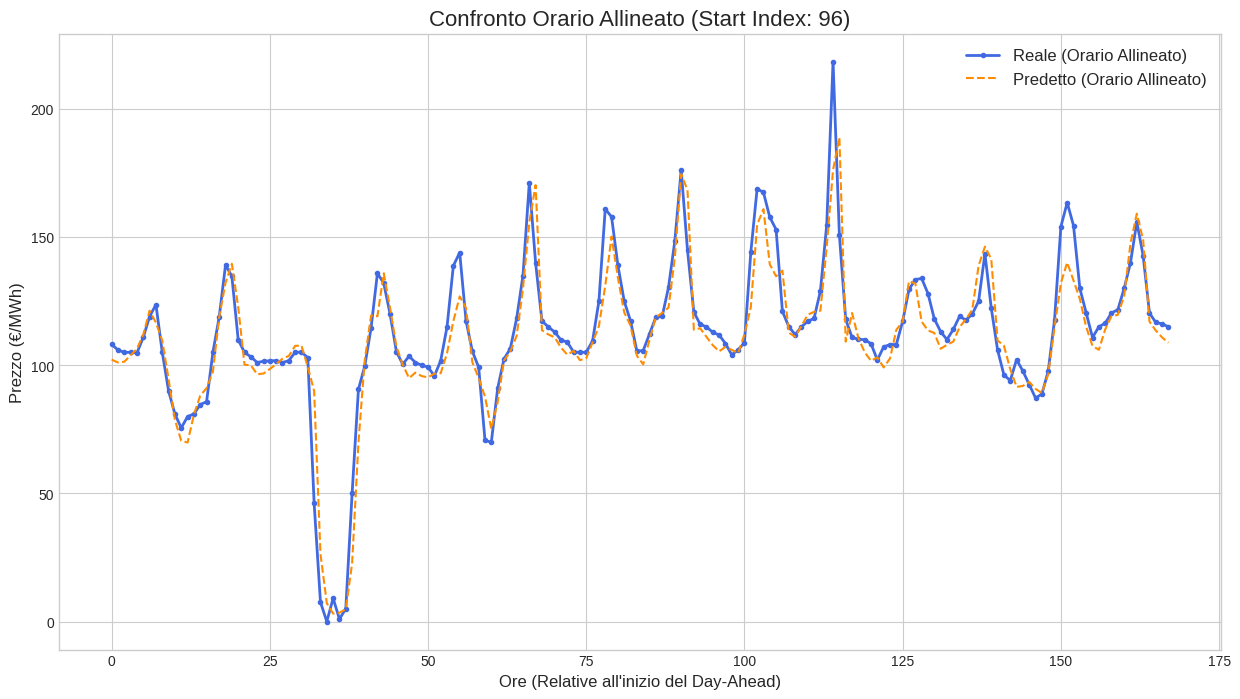

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Proviamo con 96 ore 4 GIORNI DI DIFFERENZA
OFFSET_ALLINEAMENTO = 96

ORE_DA_VEDERE = 168 # Una settimana

# --- SELEZIONE DATI TRASLATI ---
# Saltiamo le prime 'OFFSET' ore per allinearci col modello giornaliero
start_idx = OFFSET_ALLINEAMENTO
end_idx = OFFSET_ALLINEAMENTO + ORE_DA_VEDERE

print(f"Sto visualizzando le ore dall'indice {start_idx} all'indice {end_idx} del test set orario.")

# Tagliamo i dati con l'offset
reale_settimana_allineata = inv_y[start_idx : end_idx]
predetto_settimana_allineata = inv_yhat[start_idx : end_idx]

# --- PLOT ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(15, 8))

# Ora l'asse X parte da 0 relativo alla finestra allineata
asse_x = range(len(reale_settimana_allineata))

ax.plot(asse_x, reale_settimana_allineata, label='Reale (Orario Allineato)', color='royalblue', linewidth=2, marker='o', markersize=3)
ax.plot(asse_x, predetto_settimana_allineata, label='Predetto (Orario Allineato)', color='darkorange', linestyle='--')

# --- FORMATTAZIONE ---
ax.set_title(f'Confronto Orario Allineato (Start Index: {start_idx})', fontsize=16)
ax.set_ylabel('Prezzo (€/MWh)', fontsize=12)
ax.set_xlabel(f"Ore (Relative all'inizio del Day-Ahead)", fontsize=12)


ax.legend(fontsize=12)
plt.show()

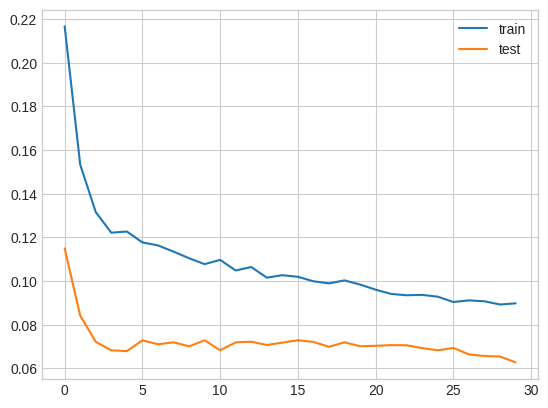

In [18]:
# plot history
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend()
pyplot.show()

12. Strategia Multi-Step: Previsione Day-Ahead (24 Ore)
In questa fase, l'obiettivo si sposta verso uno scenario di mercato reale: la previsione dell'intero profilo orario del giorno successivo (Day-Ahead Forecasting). A differenza del modello precedente, che prevedeva solo l'istante t+1, qui viene implementata una strategia Direct Multi-Output: la rete neurale dovrà generare simultaneamente un vettore di 24 valori (i prezzi dalle 00:00 alle 23:00 del giorno target).

Parametri della Configurazione:

Input Window (N
IN
​
 ): 168 ore (1 settimana esatta). L'aumento della finestra storica è necessario per catturare la stagionalità settimanale completa (es. la differenza tra Lunedì e Domenica).

Forecast Horizon (N
OUT
​
 ): 24 ore.

Filtraggio del Target: La trasformazione series_to_supervised genera inizialmente tutte le feature future. Attraverso un'operazione di slicing avanzato, isoliamo esclusivamente la variabile Prezzo per le 24 ore future, scartando le previsioni delle variabili esogene (carico, meteo) che non sono oggetto di stima diretta in questo modulo.


In [58]:

# Definisci i parametri della finestra temporale
N_IN = 168
N_OUT = 24
N_FEATURES = 3

# TRASFORMA IL SET DI TRAINING E TEST
reframed_train = series_to_supervised(scaled_train, n_in=N_IN, n_out=N_OUT)
reframed_test = series_to_supervised(scaled_test, n_in=N_IN, n_out=N_OUT)


# --- SOSTITUISCI IL VECCHIO CODICE CON QUESTO ---

# Divisione in INPUT (X) e OUTPUT (y)
train_values = reframed_train.values
test_values = reframed_test.values

# 1. Dividi correttamente X e y
n_input_cols = N_IN * N_FEATURES
train_X, train_y_full = train_values[:, :n_input_cols], train_values[:, n_input_cols:]
test_X, test_y_full = test_values[:, :n_input_cols], test_values[:, n_input_cols:]

# 2. Seleziona solo la colonna del prezzo per l'output
# Vogliamo predire la terza feature (indice 2, perché si parte da 0).
# Selezioniamo ogni terza colonna dall'output completo.
train_y = train_y_full[:, N_FEATURES-1::N_FEATURES]
test_y = test_y_full[:, N_FEATURES-1::N_FEATURES]


# --- Verifica finale. ORA LE FORME SARANNO CORRETTE ---
print("--- Set di Training ---")
print("Forma di train_X:", train_X.shape)
print("Forma di train_y:", train_y.shape)
print("\n--- Set di Test ---")
print("Forma di test_X:", test_X.shape)
print("Forma di test_y:", test_y.shape)

--- Set di Training ---
Forma di train_X: (23665, 504)
Forma di train_y: (23665, 24)

--- Set di Test ---
Forma di test_X: (1969, 504)
Forma di test_y: (1969, 24)


In [59]:
from keras.models import Sequential, Model
from keras.layers import LSTM, Dense, Input, Conv1D, MaxPooling1D, Bidirectional, MultiHeadAttention, GlobalAveragePooling1D

# --- 1. Parametri ---
N_IN = 168
N_OUT = 24
N_FEATURES = 3


print(f"Forma di train_X PRIMA del reshape: {train_X.shape}")
train_X = train_X.reshape((train_X.shape[0], N_IN, N_FEATURES))
test_X = test_X.reshape((test_X.shape[0], N_IN, N_FEATURES))
print(f"Forma di train_X DOPO il reshape: {train_X.shape}")
# Definisci il modello
model = Sequential()
# 1. STRATO CONVOLUZIONALE 1D
# Questo strato analizza la sequenza per trovare pattern locali.
model.add(Conv1D(filters=256, kernel_size=3, activation='relu', input_shape=(N_IN, N_FEATURES)))

# 2. STRATO DI MAXPOOLING - Invariato
# Riduce la lunghezza della sequenza, mantenendo le feature più rilevanti.
model.add(MaxPooling1D(pool_size=2))
model.add(Bidirectional(LSTM(70)))

# 4. STRATO DI OUTPUT

# Aggiungi gli altri strati ovvero  le 24 ore
model.add(Dense(N_OUT ))
model.compile(loss='mse', optimizer='adam')

# Stampa un riepilogo per verificare che la forma sia corretta
print("Riepilogo del Modello Aggiornato:")
model.summary()

# Ora l'addestramento funzionerà perché le dimensioni corrispondono
history = model.fit(
    train_X,
    train_y,
    epochs=30, #anche se dopo le 10 smette di imparare sensibilmente
    batch_size=64,
    validation_data=(test_X, test_y),
    verbose=2,
    shuffle=False
)


Forma di train_X PRIMA del reshape: (23665, 504)
Forma di train_X DOPO il reshape: (23665, 168, 3)
Riepilogo del Modello Aggiornato:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)              │ (None, 166, 256)       │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 83, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_10                │ (None, 140)            │       183,120 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 24)             │         3,384 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 189,064 (738.53 KB)

 Trainable params: 189,064 (738.53 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
370/370 - 7s - 18ms/step - loss: 0.3005 - val_loss: 0.0471
Epoch 2/30
370/370 - 4s - 12ms/step - loss: 0.2678 - val_loss: 0.0409
Epoch 3/30
370/370 - 5s - 12ms/step - loss: 0.2521 - val_loss: 0.0362
Epoch 4/30
370/370 - 4s - 12ms/step - loss: 0.2461 - val_loss: 0.0358
Epoch 5/30
370/370 - 4s - 11ms/step - loss: 0.2278 - val_loss: 0.0361
Epoch 6/30
370/370 - 5s - 12ms/step - loss: 0.1990 - val_loss: 0.0349
Epoch 7/30
370/370 - 4s - 11ms/step - loss: 0.1856 - val_loss: 0.0332
Epoch 8/30
370/370 - 4s - 12ms/step - loss: 0.1683 - val_loss: 0.0314
Epoch 9/30
370/370 - 5s - 12ms/step - loss: 0.1465 - val_loss: 0.0306
Epoch 10/30
370/370 - 4s - 12ms/step - loss: 0.1375 - val_loss: 0.0293
Epoch 11/30
370/370 - 4s - 12ms/step - loss: 0.1250 - val_loss: 0.0284
Epoch 12/30
370/370 - 5s - 12ms/step - loss: 0.1230 - val_loss: 0.0277
Epoch 13/30
370/370 - 4s - 12ms/step - loss: 0.1092 - val_loss: 0.0275
Epoch 14/30
370/370 - 4s - 12ms/step - loss: 0.1099 - val_loss: 0.0271
Epoch 15/30
370

In [54]:
import numpy as np
from keras.models import Model
from keras.layers import Input, LSTM, Dense, Conv1D, MaxPooling1D, Bidirectional, Attention, GlobalAveragePooling1D

# --- 1. Parametri ---
N_IN = 168
N_FEATURES = 3
N_OUT = 24  # Previsione Multi-step (24 ore/step futuri)

# --- 2. Reshape dei Dati
train_X = train_X.reshape((train_X.shape[0], N_IN, N_FEATURES))
test_X = test_X.reshape((test_X.shape[0], N_IN, N_FEATURES))

print(f"Shape Input Train: {train_X.shape}") # Deve essere (N, 168, 3)
print(f"Shape Input Test: {test_X.shape}")

# --- 3. Definizione Modello FUNZIONALE (VMD-ATT-LSTM Style) ---

# 1. INPUT
inputs = Input(shape=(N_IN, N_FEATURES))

# 2. CNN (Feature Extraction)
# Output atteso: [batch, 166, 256]
cnn_out = Conv1D(filters=256, kernel_size=3, activation='relu')(inputs)

# 3. POOLING
# Output atteso: [batch, 83, 256]
cnn_out = MaxPooling1D(pool_size=2)(cnn_out)

# 4. LSTM BIDIREZIONALE (Sequence Processing)
# Nota: return_sequences=True è OBBLIGATORIO qui per far funzionare l'attenzione dopo.
# Output atteso: [batch, 83, 140] (70 unità * 2 direzioni)
lstm_out = Bidirectional(LSTM(70, return_sequences=True))(cnn_out)

# 5. ATTENZIONE (Post-LSTM)
# Input e Output sono la stessa sequenza
attn_out = Attention()([lstm_out, lstm_out])

# 6. POOLING FINALE
# L'attenzione restituisce una sequenza [batch, 83, 140].
# Dobbiamo condensarla per prevedere i 24 valori. Usiamo la media globale.
pooled_out = GlobalAveragePooling1D()(attn_out)

# 7. OUTPUT
# Output shape: [batch, 24]
outputs = Dense(N_OUT)(pooled_out)

# Creazione Modello
model = Model(inputs=inputs, outputs=outputs)

# --- Fine Definizione ---

model.compile(loss='mae', optimizer='adam')

print("Riepilogo del Modello CNN-BiLSTM-ATTENTION (168->24):")
model.summary()

# Addestramento
history = model.fit(
    train_X,
    train_y,
    epochs=50,
    batch_size=64,
    validation_data=(test_X, test_y),
    verbose=2,
    shuffle=False
)

Shape Input Train: (23665, 168, 3)
Shape Input Test: (1969, 168, 3)
Riepilogo del Modello CNN-BiLSTM-ATTENTION (168->24):


Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 168, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 166, 256)  │      2,560 │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_9     │ (None, 83, 256)   │          0 │ conv1d_9[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_9     │ (None, 83, 140)   │    183,120 │ max_pooling1d_9[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_3         │ (None, 83, 140)   │          0 │ bidirectional_9[… │
│ (Attention)         │                   │            │ bidirectional_9[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 140)       │          0 │ attention_3[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 24)        │      3,384 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 189,064 (738.53 KB)

 Trainable params: 189,064 (738.53 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


PREVISIONE 24 H


13. Post-Processing e Ricostruzione Dimensionale (Day-Ahead)
Il modello neurale restituisce un output vettoriale di dimensione (Samples,24), corrispondente alle previsioni normalizzate per le 24 ore successive. Per ottenere valori interpretabili (in €/MWh), è necessario applicare l'inversione della trasformazione (Inverse Transform).

Problematica Tecnica: Il RobustScaler utilizzato in fase di pre-processing è stato inizializzato su una matrice a 3 feature (N×3: Prezzo, Carico, ecc.). Tuttavia, l'output del modello contiene 24 colonne (tutte riferite alla variabile "Prezzo" in istanti diversi). Questa discrepanza dimensionale impedisce l'applicazione diretta dell'inversione.

Soluzione Implementata: È stata sviluppata una procedura di Flattening & Reshaping:

Linearizzazione: L'intera matrice delle previsioni viene "appiattita" in un unico vettore colonna.

Matrice di Ricostruzione: Si genera una matrice temporanea compatibile con lo Scaler, inserendo i valori predetti nella colonna target e riempiendo di zeri le feature ausiliarie.

Inversione e Reshape: Dopo aver applicato inverse_transform, i valori vengono estratti e rimodellati nella forma originale (Samples,24).


In [60]:
import numpy as np

# --- 1. Get Predictions
# Reshape test_X to the 3D format the model expects
test_X_reshaped = test_X.reshape((test_X.shape[0],168, 3))
yhat = model.predict(test_X_reshaped)
# The shape of yhat is now (number_of_samples, 24)

# --- 2. Inverse Transform Predictions
inv_yhat_matrix = np.zeros((yhat.shape[0] * yhat.shape[1], N_FEATURES))
inv_yhat_matrix[:, -1] = yhat.flatten()
inv_yhat_full = scaler.inverse_transform(inv_yhat_matrix)

# Extract only the column with our predictions and reshape it back to (samples, 24)
inv_yhat = inv_yhat_full[:, -1].reshape(yhat.shape)


# --- 3. Inverse Transform Actual Values (Corrected Logic) ---
# Do the exact same process for the true values (test_y)
inv_y_matrix = np.zeros((test_y.shape[0] * test_y.shape[1], N_FEATURES))
inv_y_matrix[:, -1] = test_y.flatten()
inv_y_full = scaler.inverse_transform(inv_y_matrix)
inv_y = inv_y_full[:, -1].reshape(test_y.shape)


# --- 4. Print Results ---
# Now inv_yhat and inv_y are both in shape (samples, 24)
print("Shape of final predictions:", inv_yhat.shape)
print("Shape of final actuals:", inv_y.shape)
print("\nPredicted values for the first sample (24 hours):", inv_yhat[0])
print("\nReal values for the first sample (24 hours):", inv_y[0])

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Shape of final predictions: (1969, 24)
Shape of final actuals: (1969, 24)

Predicted values for the first sample (24 hours): [109.77595503 102.31550908 108.82788013  98.15855552 107.07300762
 114.34730574 119.08677136 114.88085113 107.26518935  90.40076758
  87.23341157  77.45926495  75.94325364  74.25805619  75.12906497
  89.56477986 108.14633702 123.37495334 144.04735336 136.97134324
 124.57466672 114.53980338 110.28127036 108.75991165]

Real values for the first sample (24 hours): [108.14 106.   105.   105.1  104.82 110.93 119.02 123.67 105.1   90.
  81.    75.54  80.    81.    84.65  85.8  105.   118.91 139.15 134.67
 110.   105.   103.32 101.08]


MAPE Error: 15.5652923474
--- Metriche di Valutazione del Modello ---
 RMSE: 18.7502
 MAE:  13.5437
MAPE Error: 15.5652923474


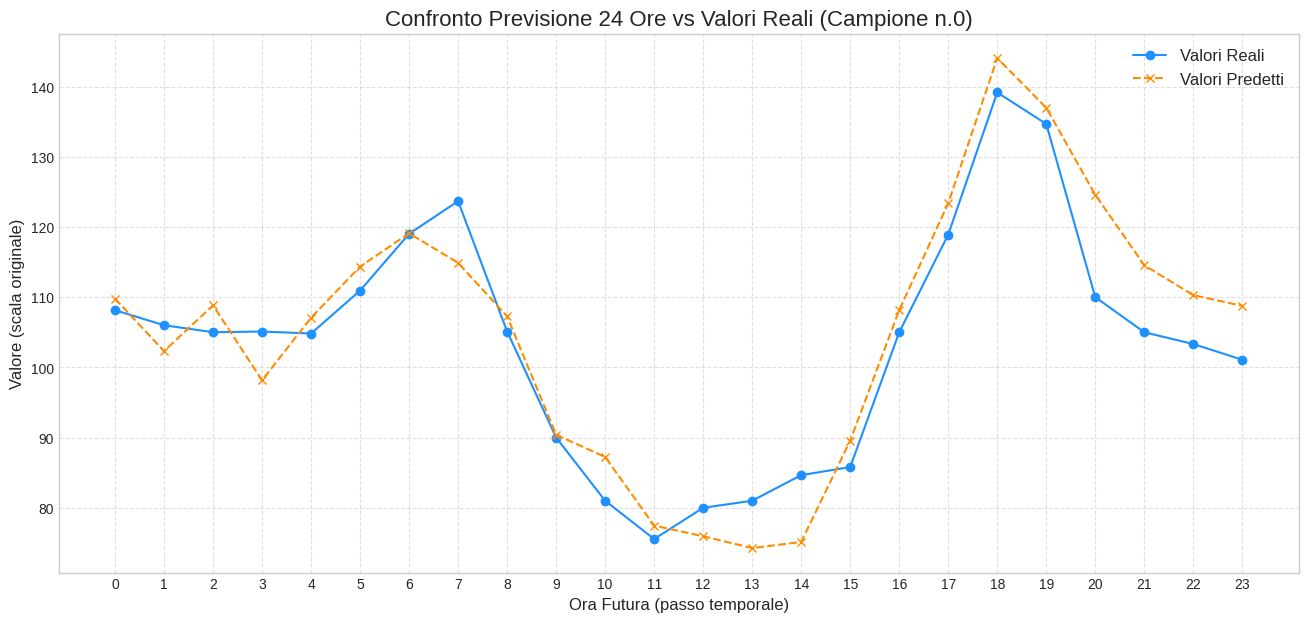

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error



# --- 1. Calcolo delle Metriche di Errore ---
# Le metriche vengono calcolate su tutte le previsioni del test set.

# RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(inv_y, inv_yhat))

# MAE (Mean Absolute Error)
mae = mean_absolute_error(inv_y, inv_yhat)

# --- CORRECTED MAPE FUNCTION ---
def mean_absolute_percentage_error_safe(y_true, y_pred):
    # Convert inputs to numpy arrays
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # Create a mask to select only the elements where the true value is NOT zero
    non_zero_mask = y_true != 0

    # Calculate MAPE only on these non-zero elements
    # This prevents division by zero and the resulting 'inf'
    mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

    return mape


#CALCOLO MAPE
error4 = mean_absolute_percentage_error_safe(inv_y, inv_yhat)


print(f'MAPE Error: {error4:11.10f}')



print("--- Metriche di Valutazione del Modello ---")
print(f" RMSE: {rmse:.4f}")
print(f" MAE:  {mae:.4f}")
print(f'MAPE Error: {error4:11.10f}')


# --- 2. Creazione del Grafico di Confronto
sample_index = 0
true_values_sample = inv_y[sample_index]
predicted_values_sample = inv_yhat[sample_index]

# Creiamo il grafico
plt.figure(figsize=(16, 7))
plt.plot(true_values_sample, label='Valori Reali', color='dodgerblue', marker='o', linestyle='-')
plt.plot(predicted_values_sample, label='Valori Predetti', color='darkorange', marker='x', linestyle='--')

# Aggiungiamo titoli e legende per chiarezza
plt.title(f'Confronto Previsione 24 Ore vs Valori Reali (Campione n.{sample_index})', fontsize=16)
plt.xlabel('Ora Futura (passo temporale)', fontsize=12)
plt.ylabel('Valore (scala originale)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(np.arange(0, 24, 1)) # Mostra tutte le 24 ore sull'asse X

# Mostra il grafico
plt.show()

In [62]:


print("--- CONTROLLO DATI ---")
# Stampa le prime 5 ore del Giorno 1 (indice 0)
print("Giorno 1 (prime 5 ore):", inv_y[0, :5])
# Stampa le prime 5 ore del Giorno 2 (indice 1)
print("Giorno 2 (prime 5 ore):", inv_y[1, :5])

# Se i due array qui sopra sono DIVERSI, il tuo grafico è CORRETTO
# e stai solo vedendo la normale stagionalità.

# --- 2. Creazione di un Grafico UNICO e CONTINUO ...

--- CONTROLLO DATI ---
Giorno 1 (prime 5 ore): [108.14 106.   105.   105.1  104.82]
Giorno 2 (prime 5 ore): [106.   105.   105.1  104.82 110.93]


Sto costruendo un grafico continuo per 7 giorni (168 ore)...


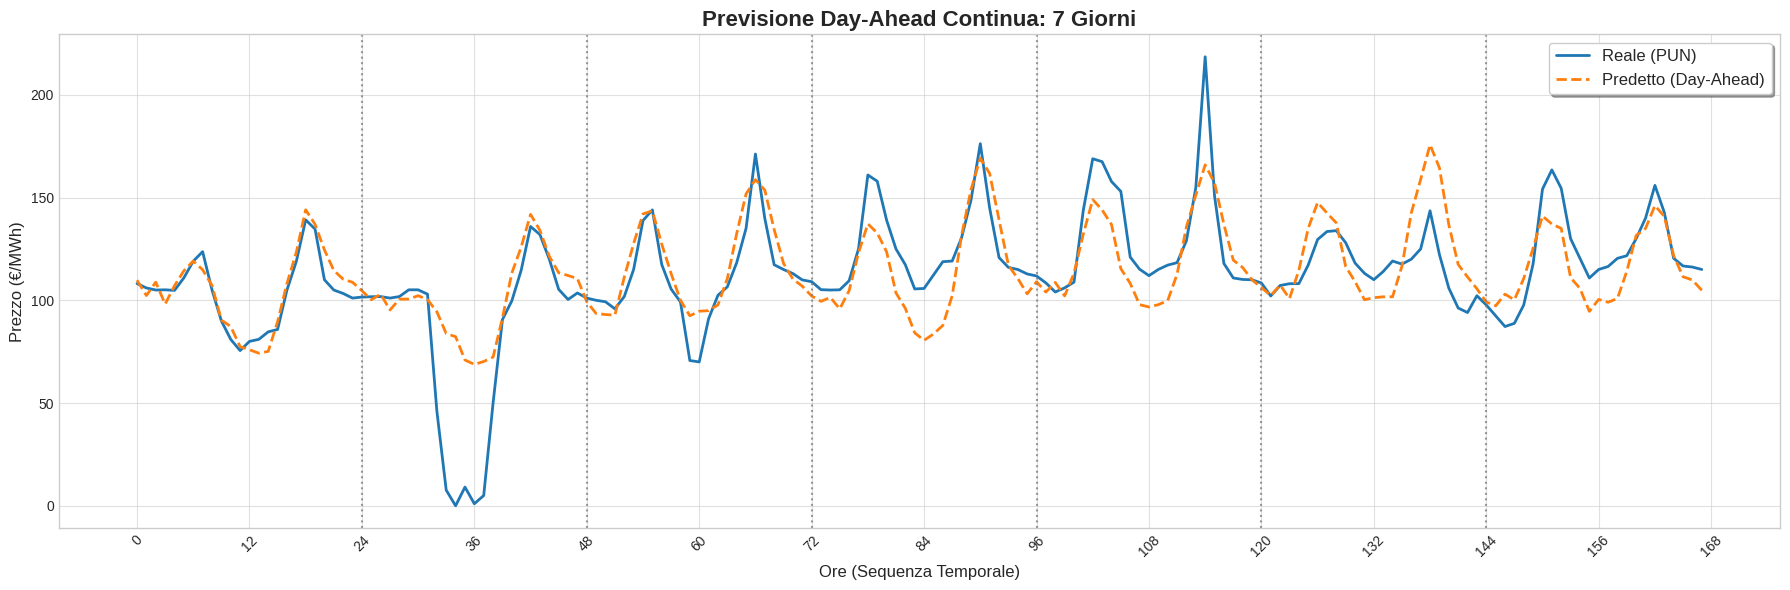

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURAZIONE GRAFICO CONTINUO


NUM_GIORNI = 7
ORE_PER_GIORNO = 24
TOTAL_ORE = NUM_GIORNI * ORE_PER_GIORNO

print(f"Sto costruendo un grafico continuo per {NUM_GIORNI} giorni ({TOTAL_ORE} ore)...")
indices_to_plot = [i * 24 for i in range(NUM_GIORNI)]

# Controllo anti-crash
if indices_to_plot[-1] >= len(inv_y):
    print(" Attenzione: Non ho abbastanza dati per 7 giorni completi nel test set.")
    # Ricalcolo per prendere il massimo possibile
    max_days = len(inv_y) // 24
    indices_to_plot = [i * 24 for i in range(max_days)]
    NUM_GIORNI = max_days
    TOTAL_ORE = NUM_GIORNI * 24
    print(f"Ridotto a {NUM_GIORNI} giorni disponibili.")
true_samples = inv_y[indices_to_plot]        # Shape: (7, 24)
predicted_samples = inv_yhat[indices_to_plot] # Shape: (7, 24)
true_continuous = true_samples.reshape(-1)
predicted_continuous = predicted_samples.reshape(-1)


# --- PLOT ---
plt.figure(figsize=(18, 6))

# Plot Reale
plt.plot(true_continuous, label='Reale (PUN)', color='#1f77b4', linewidth=2)

# Plot Predetto
plt.plot(predicted_continuous, label='Predetto (Day-Ahead)', color='#ff7f0e', linestyle='--', linewidth=2)

# --- FORMATTAZIONE
plt.title(f'Previsione Day-Ahead Continua: {NUM_GIORNI} Giorni', fontsize=16, fontweight='bold')
plt.ylabel('Prezzo (€/MWh)', fontsize=12)
plt.xlabel('Ore (Sequenza Temporale)', fontsize=12)

# Griglia e Legenda
plt.legend(fontsize=12, loc='upper right', frameon=True, shadow=True)
plt.grid(True, which='major', linestyle='-', alpha=0.6)

# Linee verticali per separare i giorni (ogni 24 ore)
for i in range(1, NUM_GIORNI):
    plt.axvline(x=i*24, color='gray', linestyle=':', alpha=0.8)
plt.xticks(np.arange(0, TOTAL_ORE + 1, 12), rotation=45)

plt.tight_layout()
plt.show()